# LightGBM Baseline — Subway Headway Prediction

Quick comparison against TFT to establish a gradient-boosting baseline.  
Uses the **same data, same splits, same features** as the TFT training notebook.

| Model | Type | Training Time | Key Advantage |
|-------|------|---------------|---------------|
| TFT (Iter 1) | Deep learning (seq-to-seq) | ~90 min | Temporal attention, quantile PI |
| TFT (Iter 2) | Deep learning (pruned) | ~90 min | Fewer features, stronger regularization |
| **LightGBM** | **Gradient boosting** | **~60 sec** | **Fast iteration, feature importance** |

**Goal**: If LightGBM ≈ TFT MAE → the data/features are the bottleneck, not the model.  
If LightGBM >> TFT MAE → TFT's temporal modeling is earning its keep.

In [1]:
# ── Install dependencies ──────────────────────────────────────────────
%pip install lightgbm --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ── Imports ───────────────────────────────────────────────────────────
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import time
import warnings
warnings.filterwarnings('ignore')

print(f'LightGBM version: {lgb.__version__}')

LightGBM version: 4.6.0


In [3]:
# ── Load data (same parquet as TFT) ──────────────────────────────────
DATA_PATH = '../local_artifacts/processed_data/tft_training_data.parquet'

data = pd.read_parquet(DATA_PATH)
print(f'Loaded {len(data):,} rows × {data.shape[1]} columns')
print(f'Time range: {data["arrival_time"].min()} → {data["arrival_time"].max()}')
print(f'Groups: {data["group_id"].nunique()}')

Loaded 4,253,782 rows × 44 columns
Time range: 2025-02-17 10:07:03+00:00 → 2026-02-17 11:19:40+00:00
Groups: 105


## Step 1 — Train / Val / Test Splits (identical to TFT)

In [4]:
# ── Same temporal splits as TFT ──────────────────────────────────────
train_cutoff = pd.Timestamp('2025-10-29', tz='UTC')
val_cutoff   = pd.Timestamp('2025-12-23', tz='UTC')
test_cutoff  = pd.Timestamp('2026-02-17', tz='UTC')

train_mask = data['arrival_time'] < train_cutoff
val_mask   = (data['arrival_time'] >= train_cutoff) & (data['arrival_time'] < val_cutoff)
test_mask  = (data['arrival_time'] >= val_cutoff) & (data['arrival_time'] < test_cutoff)

print(f'Train: {train_mask.sum():>10,} rows')
print(f'Val:   {val_mask.sum():>10,} rows')
print(f'Test:  {test_mask.sum():>10,} rows')

Train:  2,948,562 rows
Val:      649,826 rows
Test:     652,354 rows


In [5]:
# ── Feature setup ─────────────────────────────────────────────────────
# Use ALL features from both TFT iterations (LightGBM can sort out importance itself).
# No need for encoder windows — each row is independent given its features.

TARGET = 'minutes_until_next_train'

# Categoricals: LightGBM handles these natively
CAT_COLS = ['route_id', 'stop_id', 'track']

# All numeric features (superset of both TFT Iter1 and Iter2)
NUM_COLS = [
    'station_order',
    'hour', 'day_of_week', 'month',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'is_weekend', 'is_holiday',
    'rolling_mean_3', 'rolling_std_3',
    'rolling_mean_5', 'rolling_std_5',
    'rolling_mean_10', 'rolling_max_10',
    'empirical_median',
    'headway_deviation_ratio', 'headway_deviation_signed',
    'deviation_trend', 'deviation_streak',
    'time_since_upstream_1', 'time_since_upstream_2',
    'upstream_headway_1', 'upstream_headway_2', 'upstream_headway_3',
    'upstream_deviation_ratio',
    'last_train_travel_time_1', 'travel_time_deviation_1', 'last_train_travel_time_2',
    'any_route_headway_upstream', 'any_route_time_since_upstream', 'cross_route_trains_last_10min',
    'active_trip_count',
]

FEATURE_COLS = CAT_COLS + NUM_COLS

# Filter to columns that exist in the parquet
available = [c for c in FEATURE_COLS if c in data.columns]
missing = [c for c in FEATURE_COLS if c not in data.columns]
if missing:
    print(f'⚠ Missing columns (skipped): {missing}')
FEATURE_COLS = available

# Convert categoricals to pandas category dtype
for col in CAT_COLS:
    if col in data.columns:
        data[col] = data[col].astype('category')

print(f'Features: {len(FEATURE_COLS)} ({len([c for c in CAT_COLS if c in FEATURE_COLS])} categorical, {len(FEATURE_COLS) - len([c for c in CAT_COLS if c in FEATURE_COLS])} numeric)')
print(f'Target: {TARGET}')

Features: 39 (3 categorical, 36 numeric)
Target: minutes_until_next_train


In [6]:
# ── Build LightGBM datasets ──────────────────────────────────────────
X_train = data.loc[train_mask, FEATURE_COLS]
y_train = data.loc[train_mask, TARGET]
X_val   = data.loc[val_mask, FEATURE_COLS]
y_val   = data.loc[val_mask, TARGET]
X_test  = data.loc[test_mask, FEATURE_COLS]
y_test  = data.loc[test_mask, TARGET]

cat_feature_names = [c for c in CAT_COLS if c in FEATURE_COLS]

train_ds = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_feature_names, free_raw_data=False)
val_ds   = lgb.Dataset(X_val, label=y_val, reference=train_ds, categorical_feature=cat_feature_names, free_raw_data=False)

print(f'Train: {X_train.shape}')
print(f'Val:   {X_val.shape}')
print(f'Test:  {X_test.shape}')

Train: (2948562, 39)
Val:   (649826, 39)
Test:  (652354, 39)


In [7]:
# ── CRITICAL: Shift "unknown" features to prevent target leakage ──────
# TFT only sees time_varying_unknown_reals in the ENCODER (past), never at
# the prediction step. LightGBM sees all features at the same row as the
# target, so features derived from the current row's target leak information.
#
# Fix: shift all "unknown" features by 1 row per group, so each row only
# sees the PREVIOUS observation's values (matching TFT's encoder behavior).

# These features are either directly derived from the target or are rolling
# stats that may include the current row:
LEAK_COLS = [
    # Directly derived from target
    'headway_deviation_ratio', 'headway_deviation_signed',
    'deviation_trend', 'deviation_streak',
    # Rolling stats (may include current row in window)
    'rolling_mean_3', 'rolling_std_3',
    'rolling_mean_5', 'rolling_std_5',
    'rolling_mean_10', 'rolling_max_10',
]

# Only shift columns that exist
LEAK_COLS = [c for c in LEAK_COLS if c in X_train.columns]

print(f'Shifting {len(LEAK_COLS)} features by 1 row per group to prevent leakage:')
for c in LEAK_COLS:
    print(f'  - {c}')

# Shift within each group (use group_id from original data)
for split_name, X_split in [('train', X_train), ('val', X_val), ('test', X_test)]:
    split_mask = {'train': train_mask, 'val': val_mask, 'test': test_mask}[split_name]
    group_ids = data.loc[split_mask, 'group_id']
    for col in LEAK_COLS:
        X_split[col] = X_split.groupby(group_ids)[col].shift(1)

# Drop rows with NaN from shift (first row of each group)
train_valid = X_train[LEAK_COLS[0]].notna()
val_valid   = X_val[LEAK_COLS[0]].notna()
test_valid  = X_test[LEAK_COLS[0]].notna()

X_train, y_train = X_train[train_valid], y_train[train_valid]
X_val, y_val     = X_val[val_valid], y_val[val_valid]
X_test, y_test   = X_test[test_valid], y_test[test_valid]

print(f'\nAfter shift & NaN drop:')
print(f'  Train: {X_train.shape}')
print(f'  Val:   {X_val.shape}')
print(f'  Test:  {X_test.shape}')

# Rebuild LightGBM datasets
train_ds = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_feature_names, free_raw_data=False)
val_ds   = lgb.Dataset(X_val, label=y_val, reference=train_ds, categorical_feature=cat_feature_names, free_raw_data=False)

Shifting 10 features by 1 row per group to prevent leakage:
  - headway_deviation_ratio
  - headway_deviation_signed
  - deviation_trend
  - deviation_streak
  - rolling_mean_3
  - rolling_std_3
  - rolling_mean_5
  - rolling_std_5
  - rolling_mean_10
  - rolling_max_10

After shift & NaN drop:
  Train: (2948457, 39)
  Val:   (649721, 39)
  Test:  (652249, 39)


## Step 2 — Train LightGBM (MAE objective)

In [8]:
# ── LightGBM parameters ──────────────────────────────────────────────
params = {
    'objective': 'mae',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 127,              # reasonably complex trees
    'max_depth': -1,                # no depth limit (leaf-wise growth)
    'learning_rate': 0.05,
    'n_estimators': 2000,           # high — early stopping will pick the right count
    'min_child_samples': 50,        # prevent overfitting on rare groups
    'subsample': 0.8,               # row subsampling
    'colsample_bytree': 0.8,        # feature subsampling
    'reg_alpha': 0.1,               # L1 regularization
    'reg_lambda': 1.0,              # L2 regularization
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42,
}

# ── Train with early stopping ────────────────────────────────────────
t0 = time.time()

callbacks = [
    lgb.log_evaluation(period=100),
    lgb.early_stopping(stopping_rounds=50, verbose=True),
]

model = lgb.train(
    params,
    train_ds,
    num_boost_round=2000,
    valid_sets=[train_ds, val_ds],
    valid_names=['train', 'val'],
    callbacks=callbacks,
)

elapsed = time.time() - t0
print(f'\nTraining time: {elapsed:.1f}s')
print(f'Best iteration: {model.best_iteration}')
print(f'Best val MAE:   {model.best_score["val"]["l1"]:.4f}')

Training until validation scores don't improve for 50 rounds
[100]	train's l1: 0.551107	val's l1: 0.564688
[200]	train's l1: 0.489059	val's l1: 0.50528
[300]	train's l1: 0.471316	val's l1: 0.490681
[400]	train's l1: 0.460784	val's l1: 0.48251
[500]	train's l1: 0.453315	val's l1: 0.476751
[600]	train's l1: 0.448383	val's l1: 0.473316
[700]	train's l1: 0.444669	val's l1: 0.470988
[800]	train's l1: 0.441591	val's l1: 0.469219
[900]	train's l1: 0.438699	val's l1: 0.467569
[1000]	train's l1: 0.435993	val's l1: 0.466006
[1100]	train's l1: 0.433774	val's l1: 0.464751
[1200]	train's l1: 0.431304	val's l1: 0.463431
[1300]	train's l1: 0.429296	val's l1: 0.462466
[1400]	train's l1: 0.427794	val's l1: 0.46182
[1500]	train's l1: 0.426272	val's l1: 0.461209
[1600]	train's l1: 0.424496	val's l1: 0.460415
[1700]	train's l1: 0.423425	val's l1: 0.460021
[1800]	train's l1: 0.422279	val's l1: 0.459708
[1900]	train's l1: 0.421554	val's l1: 0.459558
[2000]	train's l1: 0.421072	val's l1: 0.459485
Did not mee

## Step 3 — Test Set Evaluation

In [9]:
# ── Predictions on test set ───────────────────────────────────────────
preds = model.predict(X_test, num_iteration=model.best_iteration)
actuals = y_test.values

mae  = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))
mape = np.mean(np.abs((actuals - preds) / np.clip(actuals, 0.1, None))) * 100

print('═' * 55)
print(f'  LIGHTGBM TEST METRICS  ({len(actuals):,} samples)')
print('═' * 55)
print(f'  MAE:  {mae:.3f} minutes')
print(f'  RMSE: {rmse:.3f} minutes')
print(f'  MAPE: {mape:.1f}%')
print('═' * 55)

# ── Comparison table ──────────────────────────────────────────────────
print('\n── Model Comparison ──')
print(f'  {"Model":<20s} {"MAE":>8s} {"RMSE":>8s} {"Training":>12s}')
print(f'  {"─"*20} {"─"*8} {"─"*8} {"─"*12}')
print(f'  {"TFT Iter1":<20s} {"2.319":>8s} {"3.477":>8s} {"~90 min":>12s}')
print(f'  {"TFT Iter2":<20s} {"(running)":>8s} {"":>8s} {"~90 min":>12s}')
print(f'  {"LightGBM":<20s} {mae:>8.3f} {rmse:>8.3f} {f"{elapsed:.0f}s":>12s}')

═══════════════════════════════════════════════════════
  LIGHTGBM TEST METRICS  (652,249 samples)
═══════════════════════════════════════════════════════
  MAE:  0.473 minutes
  RMSE: 1.276 minutes
  MAPE: 17.0%
═══════════════════════════════════════════════════════

── Model Comparison ──
  Model                     MAE     RMSE     Training
  ──────────────────── ──────── ──────── ────────────
  TFT Iter1               2.319    3.477      ~90 min
  TFT Iter2            (running)               ~90 min
  LightGBM                0.473    1.276         262s


── Feature importance (gain) ──
  upstream_headway_1                   69.88%  ██████████████████████████████████
  any_route_headway_upstream            5.96%  ██
  stop_id                               5.66%  ██
  travel_time_deviation_1               4.25%  ██
  time_since_upstream_1                 3.26%  █
  upstream_headway_2                    2.80%  █
  last_train_travel_time_1              2.48%  █
  any_route_time_since_upstream         1.13%  
  upstream_deviation_ratio              0.97%  
  upstream_headway_3                    0.54%  
  time_since_upstream_2                 0.43%  
  empirical_median                      0.42%  
  last_train_travel_time_2              0.42%  
  track                                 0.20%  
  rolling_mean_5                        0.13%  
  cross_route_trains_last_10min         0.13%  
  rolling_mean_10                       0.13%  
  station_order                         0.12%  
  hour                                  0.10%  
  rolling_mea

── Feature importance (gain) ──
  upstream_headway_1                   69.88%  ██████████████████████████████████
  any_route_headway_upstream            5.96%  ██
  stop_id                               5.66%  ██
  travel_time_deviation_1               4.25%  ██
  time_since_upstream_1                 3.26%  █
  upstream_headway_2                    2.80%  █
  last_train_travel_time_1              2.48%  █
  any_route_time_since_upstream         1.13%  
  upstream_deviation_ratio              0.97%  
  upstream_headway_3                    0.54%  
  time_since_upstream_2                 0.43%  
  empirical_median                      0.42%  
  last_train_travel_time_2              0.42%  
  track                                 0.20%  
  rolling_mean_5                        0.13%  
  cross_route_trains_last_10min         0.13%  
  rolling_mean_10                       0.13%  
  station_order                         0.12%  
  hour                                  0.10%  
  rolling_mea

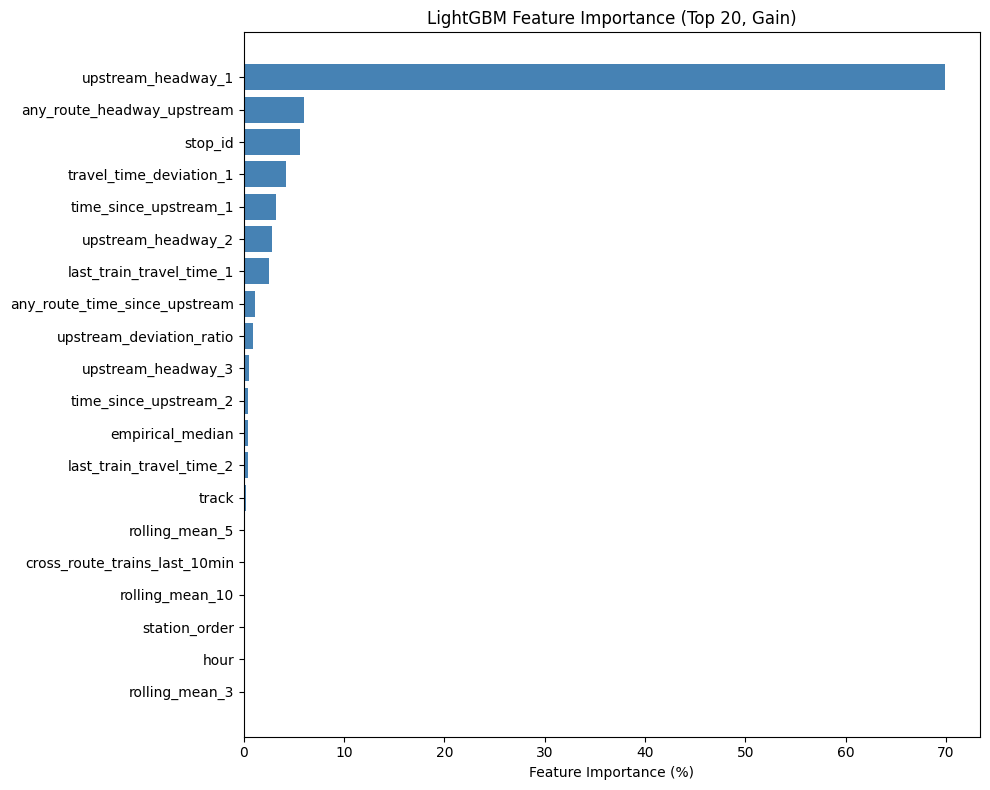

In [10]:
# ── Feature importance ────────────────────────────────────────────────
importance = pd.DataFrame({
    'feature': model.feature_name(),
    'importance': model.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False)

importance['pct'] = importance['importance'] / importance['importance'].sum() * 100

print('── Feature importance (gain) ──')
for _, row in importance.head(20).iterrows():
    bar = '█' * int(row['pct'] / 2)
    print(f"  {row['feature']:35s} {row['pct']:6.2f}%  {bar}")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
top_n = importance.head(20)
ax.barh(range(len(top_n)), top_n['pct'].values, color='steelblue')
ax.set_yticks(range(len(top_n)))
ax.set_yticklabels(top_n['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (%)')
ax.set_title('LightGBM Feature Importance (Top 20, Gain)')
plt.tight_layout()
plt.show()

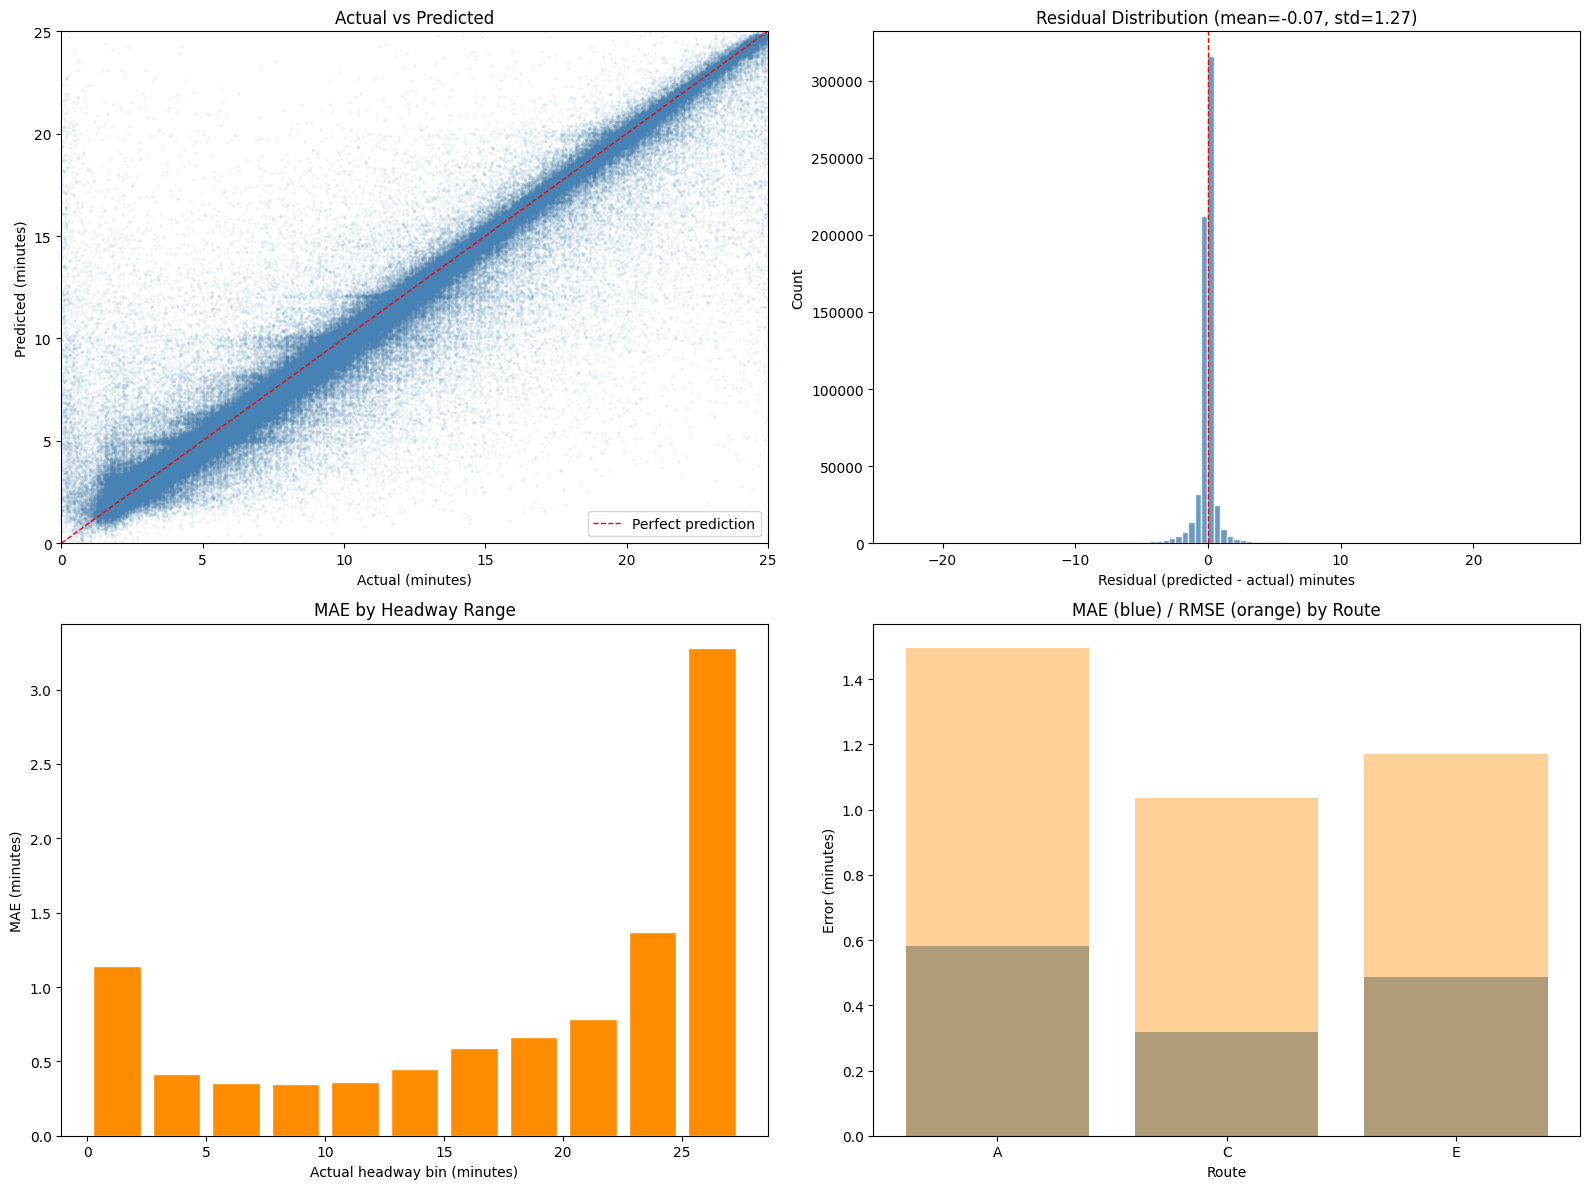

In [11]:
# ── Visualizations (same 4-panel as TFT) ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted scatter
ax = axes[0, 0]
ax.scatter(actuals, preds, alpha=0.05, s=2, c='steelblue')
lims = [0, 25]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual (minutes)')
ax.set_ylabel('Predicted (minutes)')
ax.set_title('Actual vs Predicted')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend()

# 2. Residual distribution
ax = axes[0, 1]
residuals = preds - actuals
ax.hist(residuals, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Residual (predicted - actual) minutes')
ax.set_ylabel('Count')
ax.set_title(f'Residual Distribution (mean={residuals.mean():.2f}, std={residuals.std():.2f})')

# 3. Error by actual headway (binned)
ax = axes[1, 0]
bins = np.arange(0, 30, 2.5)
bin_idx = np.digitize(actuals, bins)
bin_maes = []
bin_centers = []
for i in range(1, len(bins)):
    mask = bin_idx == i
    if mask.sum() > 0:
        bin_maes.append(np.abs(residuals[mask]).mean())
        bin_centers.append((bins[i-1] + bins[i]) / 2)
ax.bar(bin_centers, bin_maes, width=2, color='darkorange', edgecolor='white')
ax.set_xlabel('Actual headway bin (minutes)')
ax.set_ylabel('MAE (minutes)')
ax.set_title('MAE by Headway Range')

# 4. Error by route
ax = axes[1, 1]
for route in ['A', 'C', 'E']:
    rmask = X_test['route_id'] == route
    if rmask.sum() > 0:
        route_mae = np.abs(residuals[rmask]).mean()
        route_rmse = np.sqrt(np.mean(residuals[rmask]**2))
        ax.bar(route, route_mae, color='steelblue', alpha=0.7, label=f'MAE={route_mae:.2f}')
        ax.bar(route, route_rmse, color='darkorange', alpha=0.4)
ax.set_xlabel('Route')
ax.set_ylabel('Error (minutes)')
ax.set_title('MAE (blue) / RMSE (orange) by Route')

plt.tight_layout()
plt.show()

## Step 4 — Quantile Regression (p10, p50, p90)

Train separate models for each quantile to compare prediction intervals with TFT.

In [12]:
# ── Quantile models (p10, p50, p90) ──────────────────────────────────
quantiles = [0.1, 0.5, 0.9]
quantile_preds = {}

for q in quantiles:
    q_params = params.copy()
    q_params['objective'] = 'quantile'
    q_params['alpha'] = q
    q_params['metric'] = 'quantile'
    q_params['verbose'] = -1

    q_model = lgb.train(
        q_params,
        train_ds,
        num_boost_round=model.best_iteration,  # use same num rounds as MAE model
        valid_sets=[val_ds],
        valid_names=['val'],
        callbacks=[lgb.log_evaluation(period=0)],  # silent
    )
    quantile_preds[q] = q_model.predict(X_test, num_iteration=q_model.best_iteration)
    print(f'  q={q:.1f} trained')

# ── Quantile coverage ────────────────────────────────────────────────
print('\nQuantile prediction coverage (should ≈ expected):')
for q in quantiles:
    coverage = (actuals <= quantile_preds[q]).mean() * 100
    expected = q * 100
    delta = coverage - expected
    print(f'  q={q:.2f}: expected {expected:5.1f}%  actual {coverage:5.1f}%  (Δ={delta:+.1f}%)')

# 80% prediction interval: p10 to p90
lower = quantile_preds[0.1]
upper = quantile_preds[0.9]
in_interval = ((actuals >= lower) & (actuals <= upper)).mean() * 100
print(f'\n80% prediction interval coverage: {in_interval:.1f}%  (expected ~80%)')

# Median model MAE
median_mae = mean_absolute_error(actuals, quantile_preds[0.5])
print(f'Median (q50) model MAE: {median_mae:.3f} minutes')

  q=0.1 trained
  q=0.5 trained
  q=0.9 trained

Quantile prediction coverage (should ≈ expected):
  q=0.10: expected  10.0%  actual  11.3%  (Δ=+1.3%)
  q=0.50: expected  50.0%  actual  49.1%  (Δ=-0.9%)
  q=0.90: expected  90.0%  actual  88.1%  (Δ=-1.9%)

80% prediction interval coverage: 76.8%  (expected ~80%)
Median (q50) model MAE: 0.472 minutes
